# How hard is it to find a remote Python data job?

Reproducible analysis for 88,975 comments from 163 monthly Hacker News *Who is hiring?* threads. Running all cells rebuilds the eight publication charts in `charts/`.

The analysis treats one top-level comment as one post and uses deliberately transparent regular expressions. A mention is not necessarily a requirement; see the limitations at the end.

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter
import numpy as np
import pandas as pd
import mercury as mr

DATA_ROOTS = [Path.cwd(), Path.cwd() / "who-is-hiring"]
DATA_DIR = next((p for p in DATA_ROOTS if list(p.glob("who_is_hiring_????.csv.gz"))), None)
if DATA_DIR is None:
    raise FileNotFoundError("Could not find who_is_hiring_YYYY.csv.gz files")
CHART_DIR = DATA_DIR / "charts"
CHART_DIR.mkdir(exist_ok=True)

COLORS = {"navy": "#17324d", "blue": "#2878b5", "sky": "#71b7e6", "orange": "#e07a3f",
          "green": "#3a9679", "red": "#c44e52", "purple": "#8064a2", "gold": "#d4a72c", "gray": "#7a8793"}
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 180, "font.size": 10, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "axes.axisbelow": True, "axes.titlepad": 24, "grid.alpha": .18})

def save_chart(fig, filename):
    path = CHART_DIR / filename
    fig.savefig(path, bbox_inches="tight", facecolor="white")
    plt.show()
    return path

def label_last(ax, x, y, text=None, color=None, dy=0):
    ax.annotate(text or f"{y[-1]:.1f}%", (x[-1], y[-1]), xytext=(6, dy), textcoords="offset points",
                va="center", color=color, fontweight="bold")

In [2]:
# Patterns shared with the funnel app. All matching is case-insensitive except the guarded Go pattern.
PATTERNS = {
    "remote": r"remote",
    "onsite": r"\bon[- ]?site\b|\bin[- ]?office\b|\boffice[- ]based\b|\bwork(?:ing)? from (?:our|the) office\b",
    "hybrid": r"\bhybrid\b",
    "python": r"python",
    "data_ml": (r"\bdata science\b|\bdata scientist(?:s)?\b|\bdata engineer(?:s|ing)?\b|"
                r"\bmachine learning\b|\bml\b|\bmlops\b"),
    "compensation": r"[$€£]\s?\d|\bcompensation\b|\bcomp\b",
    "pay_figure": r"\$\s?\d",
    "equity": r"\bequity\b|\bstock options?\b|\boptions?\b",
    "ai": r"\bartificial intelligence\b|\bai\b",
    "llm": (r"\bllms?\b|\bgpt(?:-?\d(?:\.\d)?)?\b|\brag\b|\bgenai\b|\bgenerative ai\b|"
            r"\bopenai\b|\banthropic\b|\bchatgpt\b|\bclaude\b"),
    "crypto": r"\bcrypto\b|\bblockchain\b|\bweb3\b|\bbitcoin\b|\bethereum\b",
    "senior": r"\bsenior\b",
    "junior": r"\bjunior\b|\bnew grads?\b|\bentry[- ]level\b|\bintern(?:ship|s)?\b",
}
LANGUAGES = {
    "JavaScript / TypeScript": r"javascript|typescript|node\.?js", "Python": r"\bpython\b",
    "Ruby": r"\bruby\b|\brails\b", "Java": r"\bjava\b",
    "Go": r"(?i:\bgolang\b)|\bGo\b(?=\s*(?:[,/|+&;)]|developer|engineer|backend|experience|stack|programming))",
    "C# / .NET": r"c#|\.net", "PHP": r"\bphp\b", "Rust": r"\brust\b",
}

year_files = {int(m.group(1)): p for p in DATA_DIR.glob("who_is_hiring_*.csv.gz")
              if (m := re.fullmatch(r"who_is_hiring_(\d{4})\.csv\.gz", p.name))}
jobs = pd.concat([pd.read_csv(p).assign(year=y) for y, p in sorted(year_files.items())], ignore_index=True)
jobs["text"] = jobs["comment"].fillna("").astype(str)
jobs["thread_timestamp"] = pd.to_datetime(jobs["thread_timestamp"], utc=True)
for name, pattern in PATTERNS.items():
    jobs[name] = jobs.text.str.contains(pattern, case=False, regex=True, na=False)
for name, pattern in LANGUAGES.items():
    jobs[f"lang_{name}"] = jobs.text.str.contains(pattern, case=(name == "Go"), regex=True, na=False)

yearly_n = jobs.groupby("year").size()
print(f"{len(jobs):,} comments; {jobs.thread_id.nunique()} threads; {jobs.year.min()}–{jobs.year.max()}")
display(pd.DataFrame({"posts": yearly_n, "threads": jobs.groupby("year").thread_id.nunique()}))

88,975 comments; 163 threads; 2012–2026


,posts,threads
year,,
2012,220,1
2013,3369,12
2014,4318,12
2015,5853,10
2016,8035,12
2017,9430,12
2018,9691,12
2019,8434,12
2020,7126,12


## Funnel definitions

Each stage is cumulative. “Compensation” is intentionally broad here so it matches the interactive funnel app; the salary chart below uses a stricter numeric parser.

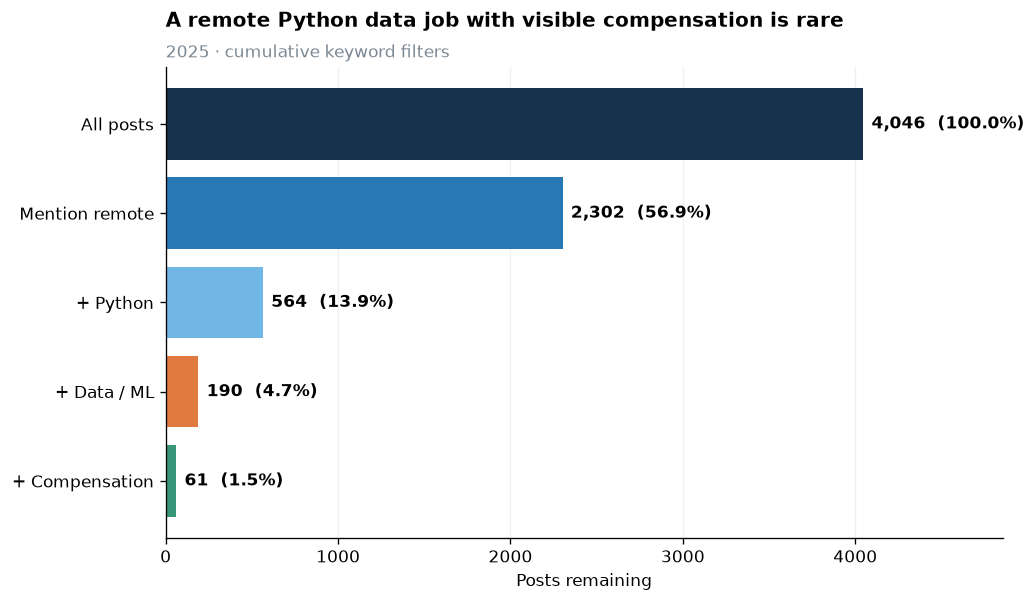

PosixPath('/home/piotr/sandbox/mercury-examples/who-is-hiring/charts/01-funnel.png')

In [3]:
FUNNEL_STAGES = [("All posts", None), ("Mention remote", "remote"), ("+ Python", "python"),
                 ("+ Data / ML", "data_ml"), ("+ Compensation", "compensation")]

def funnel_for_year(year):
    frame, mask, values = jobs.loc[jobs.year.eq(year)], None, []
    mask = pd.Series(True, index=frame.index)
    for _, column in FUNNEL_STAGES:
        if column is not None:
            mask &= frame[column]
        values.append(int(mask.sum()))
    return values

funnel_2025 = funnel_for_year(2025)
assert funnel_2025 == [4046, 2302, 564, 190, 61]
funnel_data_2025 = pd.DataFrame({"stage": [s[0] for s in FUNNEL_STAGES], "entries": funnel_2025})
display(mr.Funnel(funnel_data_2025, stage="stage", value="entries", percentage="first",
                  colors=[COLORS[x] for x in ["navy", "blue", "sky", "orange", "green"]], height=430))

# Export a static counterpart for the article's charts/01-funnel.png reference.
fig, ax = plt.subplots(figsize=(9, 5.1))
y = np.arange(len(FUNNEL_STAGES))
bars = ax.barh(y, funnel_2025, color=[COLORS[x] for x in ["navy", "blue", "sky", "orange", "green"]])
ax.invert_yaxis(); ax.set_yticks(y, [x[0] for x in FUNNEL_STAGES]); ax.set_xlabel("Posts remaining")
ax.set_title("A remote Python data job with visible compensation is rare", loc="left")
ax.text(0, 1.02, "2025 · cumulative keyword filters", transform=ax.transAxes, color=COLORS["gray"])
ax.bar_label(bars, labels=[f"{v:,}  ({v/funnel_2025[0]:.1%})" for v in funnel_2025], padding=5, fontweight="bold")
ax.set_xlim(0, max(funnel_2025) * 1.2); ax.grid(axis="y", visible=False)
save_chart(fig, "01-funnel.png")

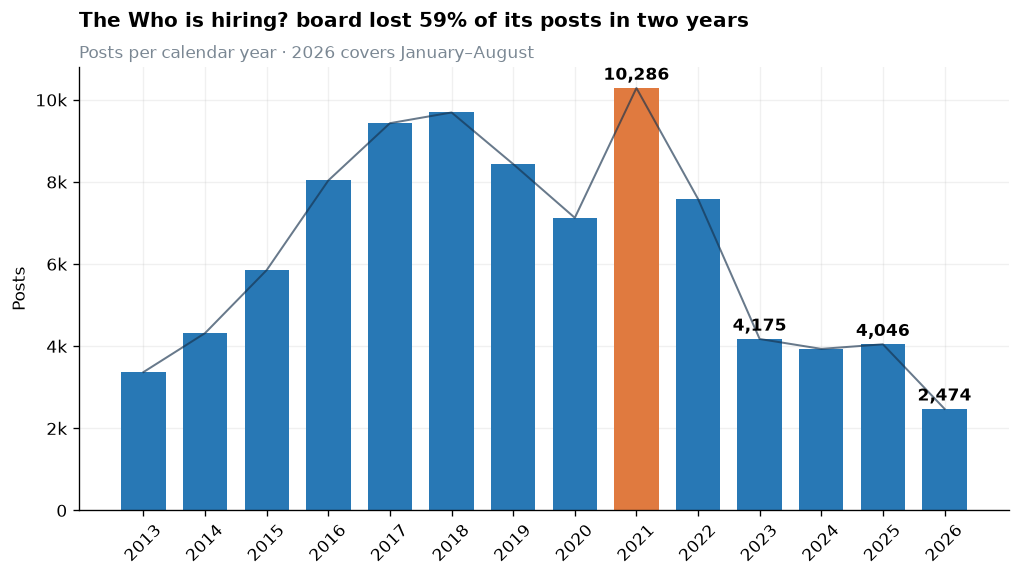

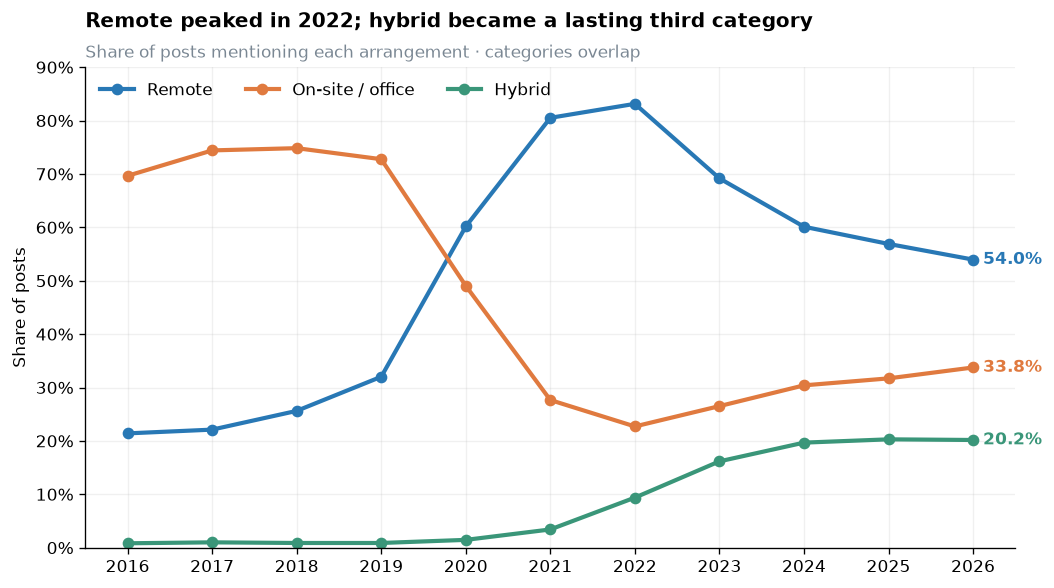

PosixPath('/home/piotr/sandbox/mercury-examples/who-is-hiring/charts/03-work-arrangement.png')

In [4]:
# Figures 2–3: volume and work arrangement.
volume = yearly_n.loc[2013:2026]
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.bar(volume.index, volume, color=[COLORS["orange"] if y == 2021 else COLORS["blue"] for y in volume.index], width=.72)
ax.plot(volume.index, volume, color=COLORS["navy"], linewidth=1.2, alpha=.65)
ax.set_title("The Who is hiring? board lost 59% of its posts in two years", loc="left")
ax.text(0, 1.02, "Posts per calendar year · 2026 covers January–August", transform=ax.transAxes, color=COLORS["gray"])
ax.set_ylabel("Posts"); ax.set_xticks(volume.index); ax.tick_params(axis="x", rotation=45)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1000:g}k" if x else "0"))
for year in [2021, 2023, 2025, 2026]:
    ax.annotate(f"{volume[year]:,}", (year, volume[year]), xytext=(0, 5), textcoords="offset points", ha="center", fontweight="bold")
save_chart(fig, "02-volume.png")

arrangement = jobs.loc[jobs.year.ge(2016)].groupby("year")[["remote", "onsite", "hybrid"]].mean().mul(100)
fig, ax = plt.subplots(figsize=(10, 5.2))
for col, label, color in [("remote", "Remote", COLORS["blue"]), ("onsite", "On-site / office", COLORS["orange"]), ("hybrid", "Hybrid", COLORS["green"])]:
    ax.plot(arrangement.index, arrangement[col], marker="o", linewidth=2.5, label=label, color=color)
    label_last(ax, arrangement.index, arrangement[col].values, color=color)
ax.set_title("Remote peaked in 2022; hybrid became a lasting third category", loc="left")
ax.text(0, 1.02, "Share of posts mentioning each arrangement · categories overlap", transform=ax.transAxes, color=COLORS["gray"])
ax.set_ylabel("Share of posts"); ax.yaxis.set_major_formatter(PercentFormatter()); ax.set_xticks(arrangement.index)
ax.legend(frameon=False, ncol=3, loc="upper left"); ax.set_ylim(0, 90)
save_chart(fig, "03-work-arrangement.png")

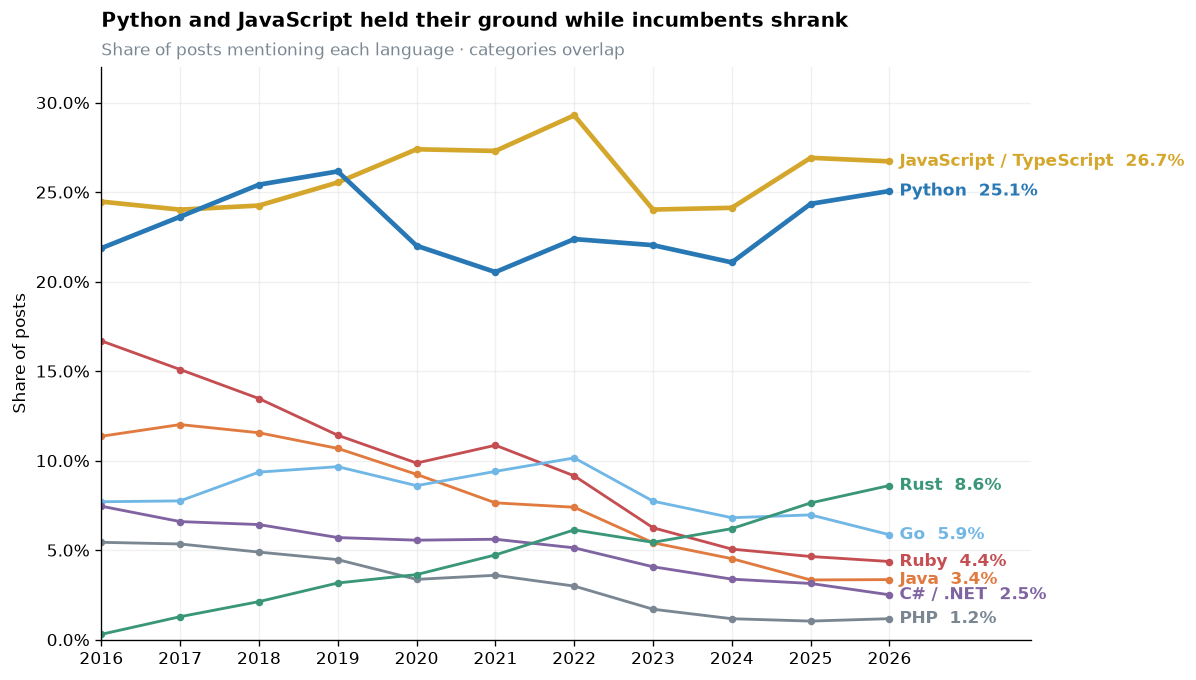

year,2016,2026
JavaScript / TypeScript,24.5,26.7
Python,21.9,25.1
Ruby,16.7,4.4
Java,11.4,3.4
Go,7.7,5.9
C# / .NET,7.5,2.5
PHP,5.4,1.2
Rust,0.3,8.6


In [5]:
# Figure 4: programming-language mentions. One post may mention multiple languages.
language_share = jobs.loc[jobs.year.ge(2016)].groupby("year")[[f"lang_{x}" for x in LANGUAGES]].mean().mul(100)
language_share.columns = list(LANGUAGES)
language_colors = [COLORS[x] for x in ["gold", "blue", "red", "orange", "sky", "purple", "gray", "green"]]
fig, ax = plt.subplots(figsize=(10, 6.2))
for (name, values), color in zip(language_share.items(), language_colors):
    ax.plot(language_share.index, values, marker="o", markersize=3.5,
            linewidth=2.8 if name in {"Python", "JavaScript / TypeScript"} else 1.7, color=color)
    label_last(ax, language_share.index, values.values, text=f"{name}  {values.iloc[-1]:.1f}%", color=color)
ax.set_title("Python and JavaScript held their ground while incumbents shrank", loc="left")
ax.text(0, 1.02, "Share of posts mentioning each language · categories overlap", transform=ax.transAxes, color=COLORS["gray"])
ax.set_ylabel("Share of posts"); ax.yaxis.set_major_formatter(PercentFormatter()); ax.set_xticks(language_share.index)
ax.set_xlim(2016, 2027.8); ax.set_ylim(0, max(32, language_share.max().max() * 1.08))
save_chart(fig, "04-languages.png")
display(language_share.loc[[2016, 2026]].T.round(1))

## Pay disclosure and advertised ranges

`pay_figure` asks only whether a post contains `$` followed by a digit. `range_mention` accepts common compact annual-range forms for disclosure rates. The midpoint parser is narrower: it requires a range beginning with `$`, normalizes `k`, infers a missing `k` from the other endpoint, and keeps plausible annual salaries from $50,000 to $1,000,000. This avoids treating hourly rates, equity percentages, dates, and funding rounds as salaries.

CPI-U values are annual averages through 2024, with article assumptions for 2025–26. Change those two values when final annual averages are available.

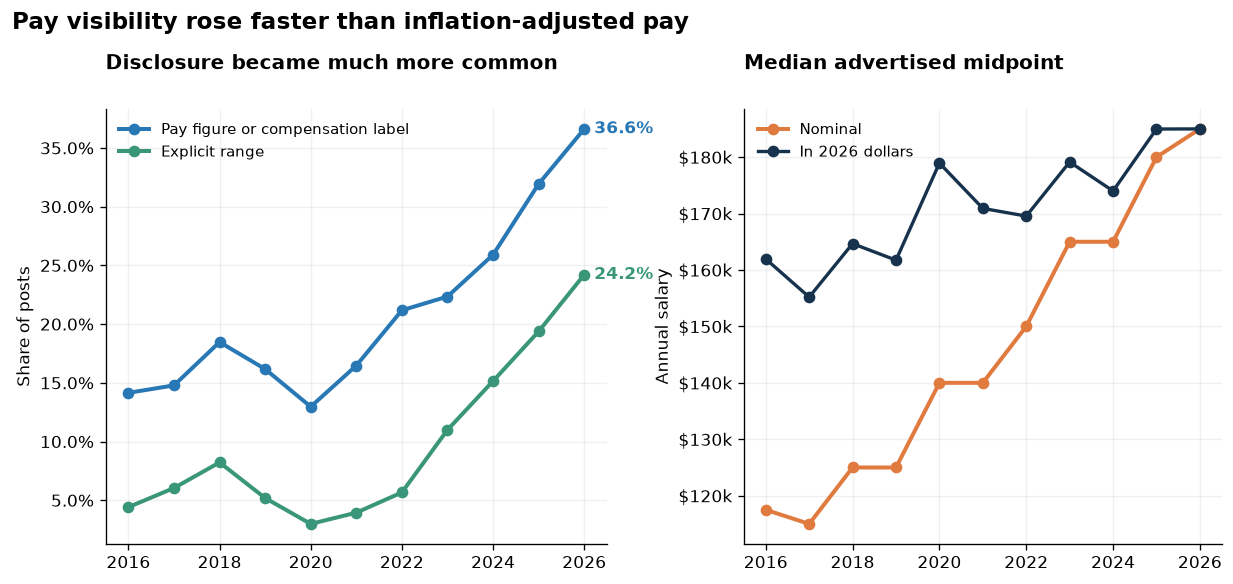

Parsed 4,134 plausible ranges. Equity: 32.0% with disclosure vs 6.8% without.


In [6]:
RANGE_MENTION_PATTERN = (r"\$\s?\d[\d,.]*\s*[kK]?\s*(?:-|–|—|to)\s*\$?\s?\d[\d,.]*\s*[kK]?|"
    r"\b\d{2,3}\s*[kK]?\s*(?:-|–|—|to)\s*\d{2,3}\s*[kK]\b|"
    r"\b\d{2,3},\d{3}\s*(?:-|–|—|to)\s*\d{2,3},\d{3}\b")
jobs["range_mention"] = jobs.text.str.contains(RANGE_MENTION_PATTERN, case=False, regex=True, na=False)
SALARY_RANGE_RE = re.compile(r"\$\s*(?P<low>[\d,.]+)\s*(?P<low_k>[kK]?)\s*(?:-|–|—|to)\s*"
                             r"\$?\s*(?P<high>[\d,.]+)\s*(?P<high_k>[kK]?)", re.I)

def advertised_midpoint(text):
    for m in SALARY_RANGE_RE.finditer(str(text)):
        low = float(m["low"].replace(",", "")) * (1000 if m["low_k"] else 1)
        high = float(m["high"].replace(",", "")) * (1000 if m["high_k"] else 1)
        if low < 1000 <= high: low *= 1000
        if high < 1000 <= low: high *= 1000
        low, high = sorted((low, high))
        if 50_000 <= low <= high <= 1_000_000:
            return (low + high) / 2
    return np.nan

jobs["salary_midpoint"] = jobs.text.map(advertised_midpoint)
salary_yearly = jobs.groupby("year").salary_midpoint.agg(["median", "count"])
assert salary_yearly.loc[2016, "median"] == 117_500 and salary_yearly.loc[2026, "median"] == 185_000
CPI = {2012:229.59, 2013:232.96, 2014:236.74, 2015:237.02, 2016:240.01, 2017:245.12, 2018:251.11,
       2019:255.66, 2020:258.81, 2021:270.97, 2022:292.66, 2023:304.70, 2024:313.69, 2025:321.9, 2026:330.8}
salary_yearly["real_2026"] = [r["median"] * CPI[2026] / CPI[y] for y, r in salary_yearly.iterrows()]
pay = jobs.loc[jobs.year.ge(2016)].groupby("year")[["compensation", "range_mention"]].mean().mul(100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.1), gridspec_kw={"width_ratios": [1.05, 1]})
for col, label, color in [("compensation", "Pay figure or compensation label", COLORS["blue"]), ("range_mention", "Explicit range", COLORS["green"])]:
    ax1.plot(pay.index, pay[col], marker="o", linewidth=2.4, label=label, color=color); label_last(ax1, pay.index, pay[col].values, color=color)
ax1.set_title("Disclosure became much more common", loc="left"); ax1.set_ylabel("Share of posts")
ax1.yaxis.set_major_formatter(PercentFormatter()); ax1.set_xticks([2016, 2018, 2020, 2022, 2024, 2026]); ax1.legend(frameon=False, fontsize=9)
s = salary_yearly.loc[2016:2026]
ax2.plot(s.index, s["median"], marker="o", linewidth=2.4, color=COLORS["orange"], label="Nominal")
ax2.plot(s.index, s["real_2026"], marker="o", linewidth=2, color=COLORS["navy"], label="In 2026 dollars")
ax2.set_title("Median advertised midpoint", loc="left"); ax2.set_ylabel("Annual salary")
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1000:.0f}k")); ax2.set_xticks([2016, 2018, 2020, 2022, 2024, 2026]); ax2.legend(frameon=False, fontsize=9)
fig.suptitle("Pay visibility rose faster than inflation-adjusted pay", x=.06, ha="left", fontsize=14, fontweight="bold")
fig.subplots_adjust(top=.82, wspace=.28); save_chart(fig, "05-pay.png")
parsed_n = int(jobs.salary_midpoint.notna().sum())
equity_rates = jobs.groupby("compensation").equity.mean().mul(100)
print(f"Parsed {parsed_n:,} plausible ranges. Equity: {equity_rates[True]:.1f}% with disclosure vs {equity_rates[False]:.1f}% without.")

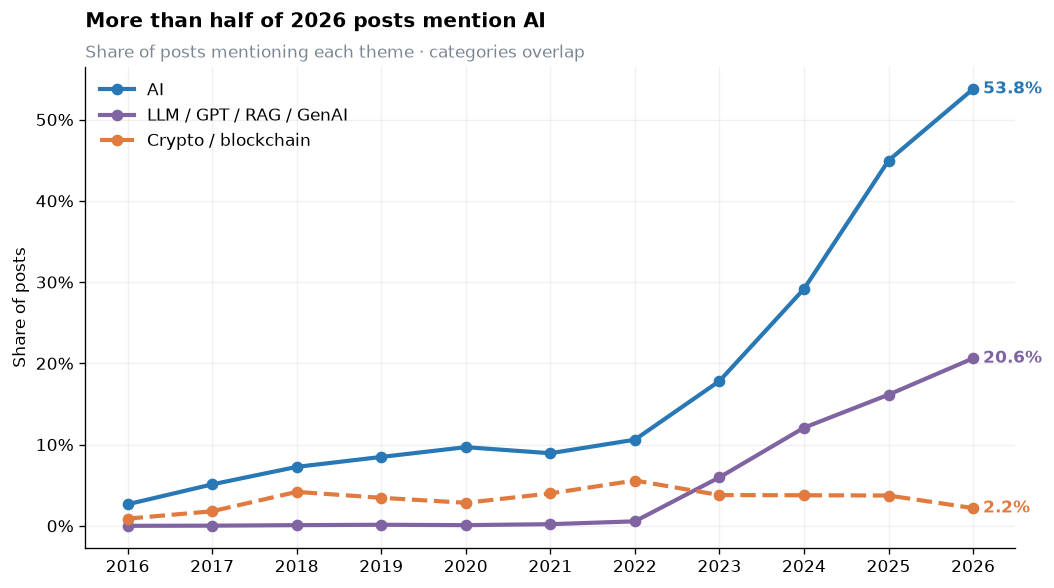

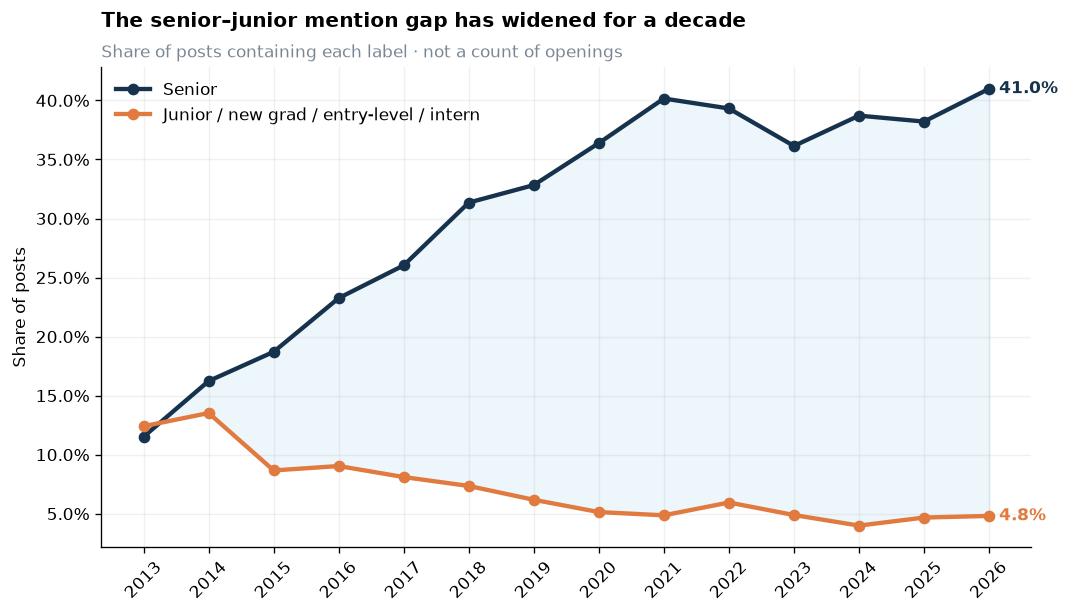

PosixPath('/home/piotr/sandbox/mercury-examples/who-is-hiring/charts/07-seniority.png')

In [7]:
# Figures 6–7: technology framing and seniority labels.
themes = jobs.loc[jobs.year.ge(2016)].groupby("year")[["ai", "llm", "crypto"]].mean().mul(100)
fig, ax = plt.subplots(figsize=(10, 5.2))
for col, label, color, style in [("ai", "AI", COLORS["blue"], "-"), ("llm", "LLM / GPT / RAG / GenAI", COLORS["purple"], "-"), ("crypto", "Crypto / blockchain", COLORS["orange"], "--")]:
    ax.plot(themes.index, themes[col], marker="o", linewidth=2.5, linestyle=style, label=label, color=color); label_last(ax, themes.index, themes[col].values, color=color)
ax.set_title("More than half of 2026 posts mention AI", loc="left")
ax.text(0, 1.02, "Share of posts mentioning each theme · categories overlap", transform=ax.transAxes, color=COLORS["gray"])
ax.set_ylabel("Share of posts"); ax.yaxis.set_major_formatter(PercentFormatter()); ax.set_xticks(themes.index); ax.legend(frameon=False)
save_chart(fig, "06-ai.png")

seniority = jobs.loc[jobs.year.ge(2013)].groupby("year")[["senior", "junior"]].mean().mul(100)
fig, ax = plt.subplots(figsize=(10, 5.2))
for col, label, color in [("senior", "Senior", COLORS["navy"]), ("junior", "Junior / new grad / entry-level / intern", COLORS["orange"] )]:
    ax.plot(seniority.index, seniority[col], marker="o", linewidth=2.6, label=label, color=color); label_last(ax, seniority.index, seniority[col].values, color=color)
ax.fill_between(seniority.index, seniority.junior, seniority.senior, color=COLORS["sky"], alpha=.12)
ax.set_title("The senior–junior mention gap has widened for a decade", loc="left")
ax.text(0, 1.02, "Share of posts containing each label · not a count of openings", transform=ax.transAxes, color=COLORS["gray"])
ax.set_ylabel("Share of posts"); ax.yaxis.set_major_formatter(PercentFormatter()); ax.set_xticks(seniority.index); ax.tick_params(axis="x", rotation=45); ax.legend(frameon=False)
save_chart(fig, "07-seniority.png")

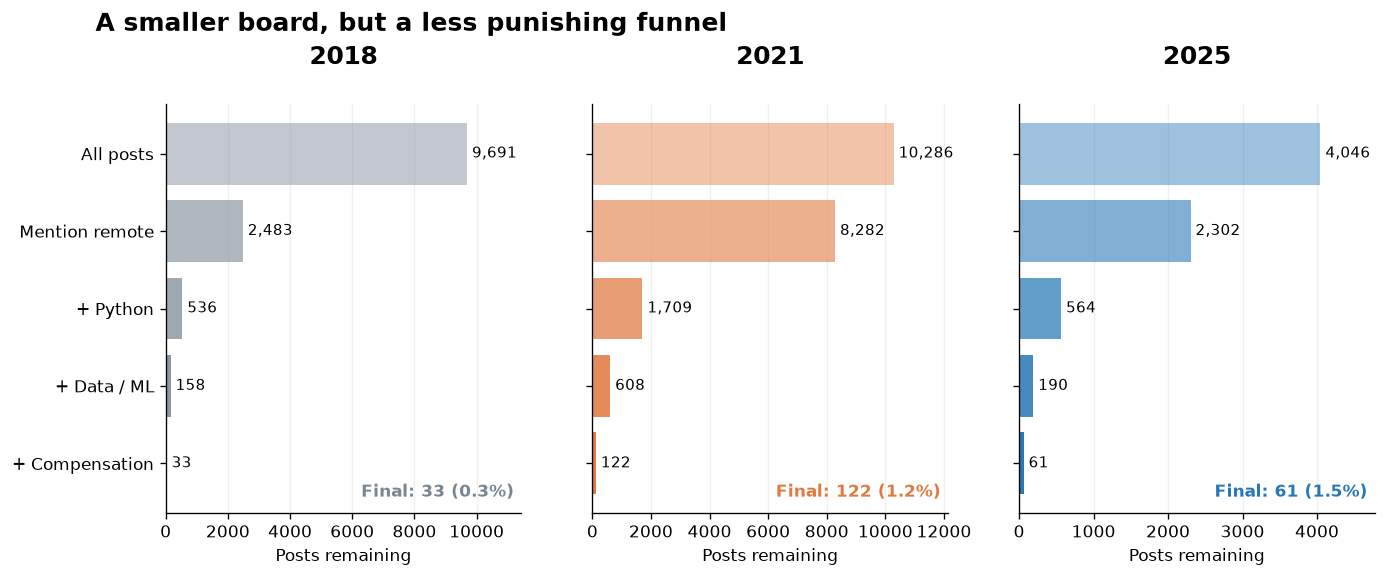

,2018,2021,2025
All posts,9691,10286,4046
Mention remote,2483,8282,2302
+ Python,536,1709,564
+ Data / ML,158,608,190
+ Compensation,33,122,61


In [8]:
# Figure 8: the same cumulative funnel in three labor markets.
compare_years = [2018, 2021, 2025]
comparison = pd.DataFrame({y: funnel_for_year(y) for y in compare_years}, index=[s[0] for s in FUNNEL_STAGES])
assert comparison.loc["+ Compensation", 2018] == 33 and comparison.loc["+ Compensation", 2025] == 61
fig, axes = plt.subplots(1, 3, figsize=(13, 4.8), sharey=True)
for ax, year, color in zip(axes, compare_years, [COLORS["gray"], COLORS["orange"], COLORS["blue"]]):
    values, y = comparison[year].values, np.arange(len(comparison))
    bar_colors = [(*plt.matplotlib.colors.to_rgb(color), alpha) for alpha in np.linspace(.45, 1, len(values))]
    bars = ax.barh(y, values, color=bar_colors)
    ax.invert_yaxis(); ax.set_yticks(y, comparison.index); ax.set_title(str(year), fontsize=15); ax.set_xlabel("Posts remaining")
    ax.bar_label(bars, labels=[f"{v:,}" for v in values], padding=3, fontsize=9); ax.set_xlim(0, max(values) * 1.18); ax.grid(axis="y", visible=False)
    ax.text(.98, .04, f"Final: {values[-1]:,} ({values[-1]/values[0]:.1%})", transform=ax.transAxes, ha="right", fontweight="bold", color=color)
fig.suptitle("A smaller board, but a less punishing funnel", x=.08, ha="left", fontsize=15, fontweight="bold")
fig.subplots_adjust(top=.82, wspace=.2); save_chart(fig, "08-funnel-years.png")
comparison

## Limitations

- One comment can advertise several roles.
- A keyword mention is not necessarily a requirement and may be negated.
- Work-arrangement formatting is inconsistent before 2016.
- Dollar salary ranges make the pay series heavily US-weighted; the range parser deliberately trades recall for interpretability.
- Hacker News is a self-selecting slice of the technology labor market.
- 2012 and 2026 are partial years (2026 contains January–August).

To test a different definition, edit the corresponding expression in `PATTERNS` or `LANGUAGES` and rerun all cells.